# EDA and Hypothesis Testing on Privately Available Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ws = pd.read_csv('Personal Workshop Data Records.csv')
print(f'Rows: {ws.shape[0]}, Columns: {ws.shape[1]}')
ws.head()

Rows: 34, Columns: 13


,Thumbnail,Workshop Item Name,Unique Visitors,Current Subscribers,Current Favorites,Collections,Comments,Stars,Ratings,Positive Ratings,Negative Ratings,Total Unique Subscribers,Total Unique Favorites
0,Animated,[ARC9] BOCW Assault Rifles,38088,21064,2232,24511,89,5,592,520,72,81902,2592
1,Animated,[ARC9] BOCW Assault Rifles DLC,20484,14750,1158,12840,57,4,286,257,29,48271,1304
2,Animated,[ARC9] BOCW Light Machine Guns,7002,7343,480,4405,19,4,127,115,12,19767,544
3,Animated,[ARC9] BOCW Melee DLC,6015,5100,392,2164,11,4,102,91,11,11466,423
4,Animated,[ARC9] BOCW Pistols,61533,45697,3349,51063,90,5,687,610,77,162051,3914


In [ ]:
ws.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Thumbnail                 34 non-null     object
 1   Workshop Item Name        34 non-null     object
 2   Unique Visitors           34 non-null     int64 
 3   Current Subscribers       34 non-null     int64 
 4   Current Favorites         34 non-null     int64 
 5   Collections               34 non-null     int64 
 6   Comments                  34 non-null     int64 
 7   Stars                     34 non-null     int64 
 8   Ratings                   34 non-null     int64 
 9   Positive Ratings          34 non-null     int64 
 10  Negative Ratings          34 non-null     int64 
 11  Total Unique Subscribers  34 non-null     int64 
 12  Total Unique Favorites    34 non-null     int64 
dtypes: int64(11), object(2)
memory usage: 3.6+ KB


In [ ]:
ws.describe().T

,count,mean,std,min,25%,50%,75%,max
Unique Visitors,34.0,14435.264706,10968.702043,4394.0,9327.50,11373.0,14039.25,61533.0
Current Subscribers,34.0,10887.882353,7806.050857,3629.0,6381.50,7971.5,12572.25,45697.0
Current Favorites,34.0,952.588235,603.594943,226.0,562.00,862.5,1133.25,3349.0
Collections,34.0,9542.058824,9387.381708,1200.0,4939.75,5913.0,13169.25,51063.0
Comments,34.0,28.323529,21.837861,3.0,12.00,22.0,38.50,90.0
Stars,34.0,4.205882,0.410426,4.0,4.00,4.0,4.00,5.0
Ratings,34.0,224.323529,128.151123,80.0,160.75,203.0,242.75,687.0
Positive Ratings,34.0,201.852941,113.724849,73.0,142.75,181.5,220.25,610.0
Negative Ratings,34.0,22.470588,15.333140,6.0,14.00,19.5,26.00,77.0
Total Unique Subscribers,34.0,49076.117647,37540.289067,8353.0,24164.75,42098.0,53736.50,162051.0


Data seems to be within limits, error with inputting values unlikely after exploratory data analysis.

# Hypothesis Testing

HT with the public dataset was a wash, nothing of significance was discovered, so I would like to attempt it again with my own records. Refer to the Hypothesis Testing folder in the repository for the randomization dotplot results.

## Unique Visitors

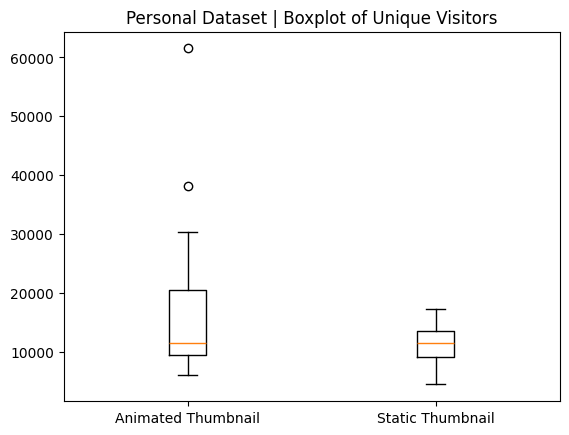


Difference in means: 6683.588235294119


In [ ]:
Df_A = ws[ws['Thumbnail'].isin(['Animated'])] # Animated df
Df_S = ws[ws['Thumbnail'].isin(['Static'])]   # Static df

bpList = [Df_A['Unique Visitors'], Df_S['Unique Visitors']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Unique Visitors')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Unique Visitors'].mean()
meanS = Df_S['Unique Visitors'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

#Df_A['Unique Visitors'].describe()
#Df_S['Unique Visitors'].describe()

There we go, the animated thumbnail has more visitors to the mod pages as expected, but is this difference significant?

**Null Hypothesis:** Thumbnail format has no effect on the number of unique visitors to the worksop page.

**Alternative Hypothesis:** Animated thumbnails has more unique visitors to the workshop page.

It is! Using a confidence level of 95%, we have obtained a p-value of 0.030, which is lower than 0.05, the value determined by our confidence level. This means we reject the null hypothesis in favor of alternative hypothesis 2.

## Current Subscribers

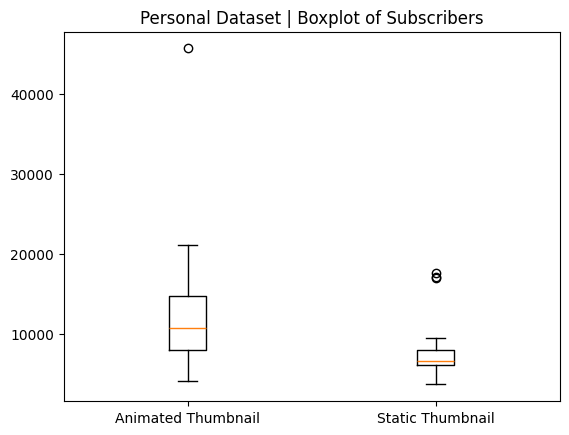


Difference in means: 4843.058823529413


In [ ]:
bpList = [Df_A['Current Subscribers'], Df_S['Current Subscribers']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Subscribers')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Current Subscribers'].mean()
meanS = Df_S['Current Subscribers'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

We can see a big difference in subscriber counts here favoring animated thumbnails.

**Null Hypothesis:** Thumbnail format has no effect on the number of subscribers to the worksop page.

**Alternative Hypothesis:** Animated thumbnails has more subscribers to the workshop page.

This is a significant difference with a p-value of 0.025, less than 0.05. We reject the null hypothesis in favor of the alternative hypothesis.

## Favorites

Does thumbnail type effect people favoriting mods? Favoriting essentially saves the addon into a users favorited addons list and likely help users make mod collections easier, as there is a dedicated tab for Favorited Addons when selecting addons to include in a collection.

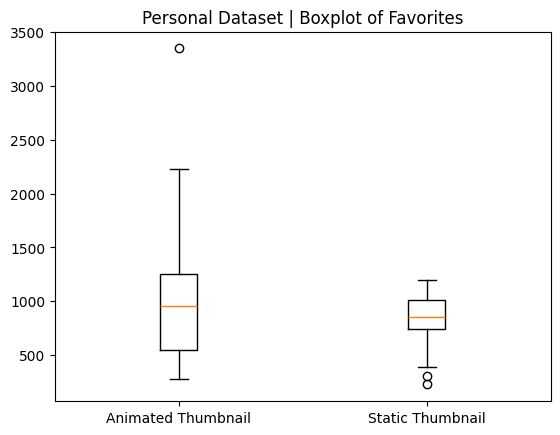


Difference in means: 289.0588235294117


In [ ]:
bpList = [Df_A['Current Favorites'], Df_S['Current Favorites']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Favorites')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Current Favorites'].mean()
meanS = Df_S['Current Favorites'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

We can say the favorites are more spread out on animated thumbnails but visually both types do not look too far apart from eachother.

**Null Hypothesis:** Thumbnail format has no effect on the number of favorites on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users favoriting the workshop page.

The difference is not significant with a p-value of 0.088, which is higher than 0.05. We could not reject the null hypothesis here.

## Collections

Collections are modpacks made by users (and sometimes mod authors) for easier distribution of mods among friends and others.

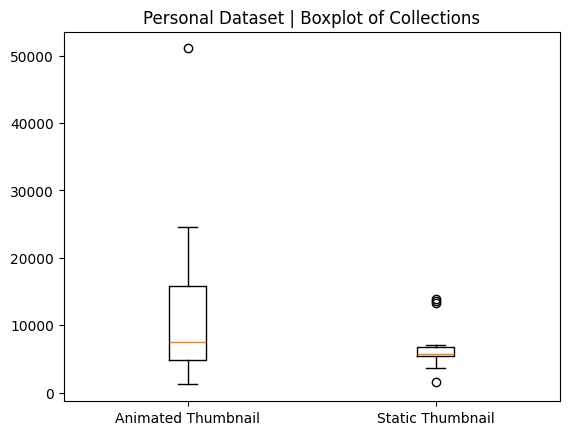


Difference in means: 5602.941176470588


In [ ]:
bpList = [Df_A['Collections'], Df_S['Collections']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Collections')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Collections'].mean()
meanS = Df_S['Collections'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

This is very surprising, static thumbnails look like they have been squashed compared to animated.

**Null Hypothesis:** Thumbnail format has no effect on the number of collections made that contain said addon.

**Alternative Hypothesis:** More collections are made from mods that have animated thumbnails.

The p-value is 0.032 which is, again, lower than 0.05, meaning we reject the null hypothesis once again.

## Comments

Are people more interested to interact on comment sections of addons that have animated thumbnails? Lets see:

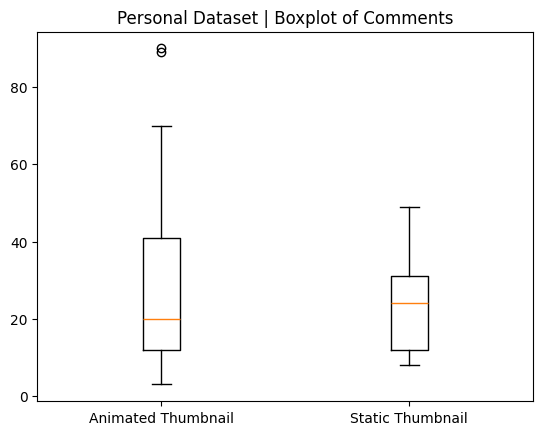


Difference in means: 8.411764705882355


In [ ]:
bpList = [Df_A['Comments'], Df_S['Comments']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Comments')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Comments'].mean()
meanS = Df_S['Comments'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Unsurprisingly the amount of comments do not really have that much relevance to the type of thumbnail.

**Null Hypothesis:** Thumbnail format has no effect on the number of comments on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users commenting the workshop page.

We obtained a p-value of 0.136 which is way higher than 0.05. Nothing of significance was found here, could not reject null hypothesis.

## Stars

Stars are from 0-5 and the underlying calculations are not clearly known for determining the star count of a workshop addon.

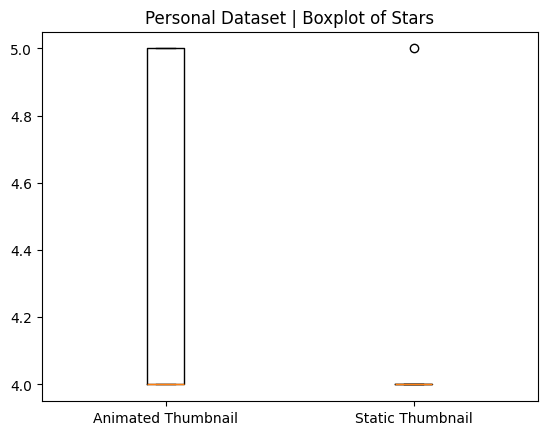


Difference in means: 0.2941176470588234


In [ ]:
bpList = [Df_A['Stars'], Df_S['Stars']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Stars')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Stars'].mean()
meanS = Df_S['Stars'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Yeah the boxplot is unreadable but we should check for significance.

**Null Hypothesis:** Thumbnail format has no effect on the number of stars on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more stars on the workshop page.

Well it seems significant, with a p-value of 0.044. The null hypothesis is rejected.

## Ratings

Ratings are the sum of positive and negative ratings, so we are looking for whether people are more interested to give ratings depending on thumbnail types.

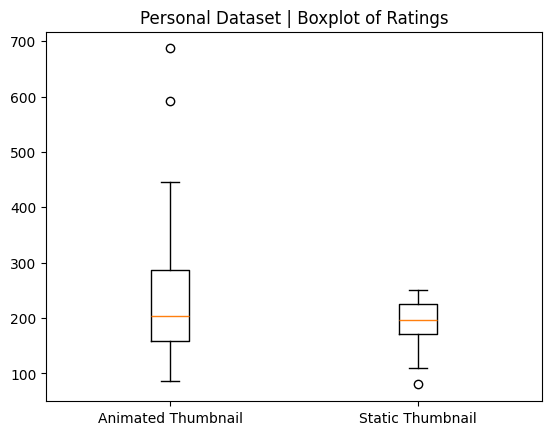


Difference in means: 73.47058823529412


In [ ]:
bpList = [Df_A['Ratings'], Df_S['Ratings']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Ratings')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Ratings'].mean()
meanS = Df_S['Ratings'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

**Null Hypothesis:** Thumbnail format has no effect on the number of ratings on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users giving ratings to the workshop page.

The ratings seems to be overall higher on my animated thumbnail mods, but this difference is almost significant, with a p-value of 0.051. Still we are unable to reject the null hypothesis.

We have some exclusive numbers from the personal dataset so we can do some testing on those as well.

# Positive Ratings

Positive ratings are essentially likes on any other media platform.

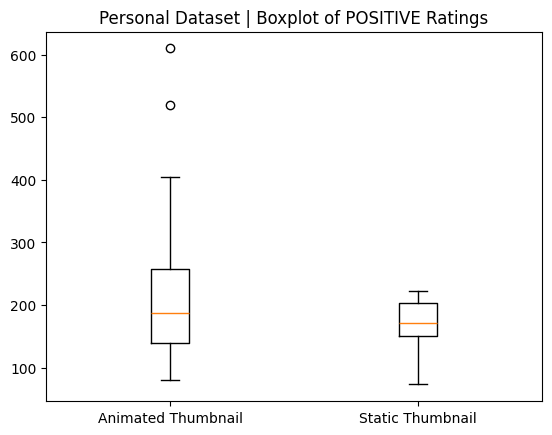


Difference in means: 68.52941176470588


In [ ]:
bpList = [Df_A['Positive Ratings'], Df_S['Positive Ratings']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of POSITIVE Ratings')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Positive Ratings'].mean()
meanS = Df_S['Positive Ratings'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

**Null Hypothesis:** Thumbnail format has no effect on the number of likes on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users liking the mod.

There is a significant amount of positive ratings on animated thumbnails, with a p-value of 0.041. We reject the null hypothesis.

# Negative Ratings

Do dislike counts have anything to do with thumbnails?

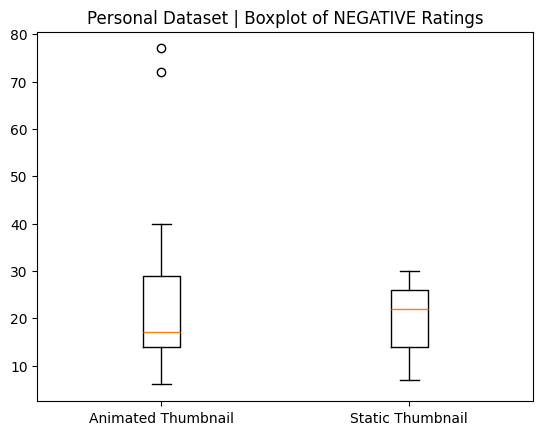


Difference in means: 4.9411764705882355


In [ ]:
bpList = [Df_A['Negative Ratings'], Df_S['Negative Ratings']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of NEGATIVE Ratings')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Negative Ratings'].mean()
meanS = Df_S['Negative Ratings'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Yeah this is a wash.

**Null Hypothesis:** Thumbnail format has no effect on the number of dislikes on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have LESS users disliking the mod.

The p-value is an astounding 0.804, meaning it is more likely for animated thumbnails to get dislikes though checking like/dislike ratios probably makes more sense. The null hypotesis cannot be rejected at all.

# Total Unique Subscribers

This metric counts everyone that has clicked the subscribe button no matter they unsubscribed later on. Basically this counts people that tried the mod, then deleted it on top of people who actually play the mod at data collection time.

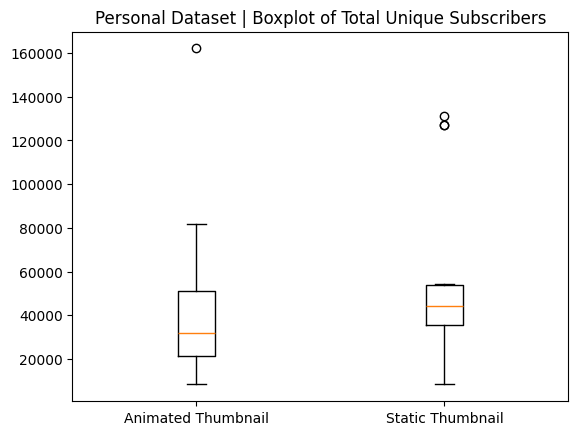


Difference in means: -9627.411764705881


In [ ]:
bpList = [Df_A['Total Unique Subscribers'], Df_S['Total Unique Subscribers']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Total Unique Subscribers')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Total Unique Subscribers'].mean()
meanS = Df_S['Total Unique Subscribers'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Well it seems animated thumbnails are doing worse here.

**Null Hypothesis:** Thumbnail format has no effect on the number of total unique subscribers on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have less users trying out the mod at least once.

P-value is 0.242 for the alternative hypothesis so nothing of significance found. We could not reject the null hypothesis.

# Total Unique Favorites

Basically what I have said for subscribers but its favorites this time.

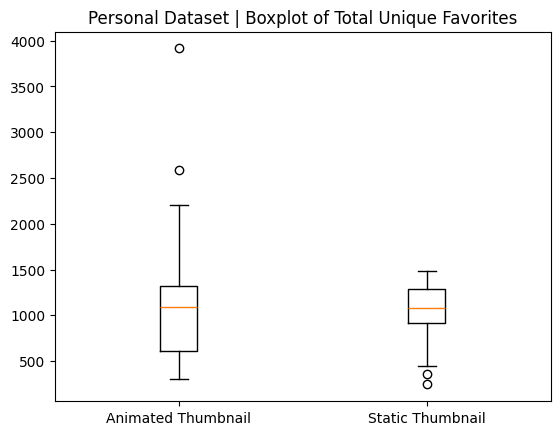


Difference in means: 244.3529411764705


In [ ]:
bpList = [Df_A['Total Unique Favorites'], Df_S['Total Unique Favorites']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Personal Dataset | Boxplot of Total Unique Favorites')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Total Unique Favorites'].mean()
meanS = Df_S['Total Unique Favorites'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

**Null Hypothesis:** Thumbnail format has no effect on the number of total unique favorites on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users favoriting the mod at one point.

After the randomization test we got a p-value of 0.245 which means we cannot reject the null hypothesis, again.

# Summary
## Statistically Significant Metrics
- Unique Visitors
- Current Subscribers
- Collections
- Stars
- Positive Ratings

## Statistically Insignificant Metrics
- Current Favorites
- Comments
- Negative Ratings
- Total Unique Subscribers
- Total Unique Favorites